### You will be required to find a publicly available dataset related to agribusiness. The dataset could be about crop yields, livestock production, weather patterns, or any other topic relevant to agribusiness. After obtaining the dataset, your task is to clean and preprocess the data. This involves handling missing values, removing duplicates, dealing with outliers, and normalizing the data if necessary. You will write a comprehensive report detailing the process you followed, challenges you encountered, and how you overcame them. The report should also include the statistical summary of the dataset. The final deliverable is a DOC file including your cleaned dataset and the detailed report. The task will be evaluated based on the complexity of the dataset chosen, the thoroughness of the cleaning process, and the clarity of the report.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import MinMaxScaler

## Load Datasets

In [3]:
df = pd.read_csv("cleaned_agri_crop_yield_dataset.csv")
df

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Area_Normalized,Annual_Rainfall_Normalized,Fertilizer_Normalized,Pesticide_Normalized,Yield_Normalized
0,Millet,2020,Kharif,Chhattisgarh,15076.5000,17031.9123,987.8,2.188493e+06,75230.8098,1.1297,0.3694,0.3421,0.4665,0.4581,0.1009
1,Sugarcane,2001,Rabi,Madhya Pradesh,6047.0700,145774.8398,1760.6,3.185354e+05,47011.8808,6.8491,0.1451,0.7265,0.0659,0.2854,1.0000
2,Barley,2015,Kharif,Chhattisgarh,4505.9600,10996.0146,1294.2,3.318065e+05,8451.0804,2.4403,0.1068,0.4945,0.0688,0.0495,0.3069
3,Soybean,1999,Kharif,Andhra Pradesh,741.3000,749.3950,300.0,9.602865e+04,1146.2010,1.0109,0.0133,0.0000,0.0183,0.0048,0.0822
4,Cotton,2014,Kharif,Madhya Pradesh,2604.4300,3865.8288,414.5,2.846358e+05,16639.2337,1.4843,0.0596,0.0570,0.0587,0.0996,0.1566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,Millet,2008,Summer,Telangana,4336.2000,7803.2247,973.6,4.686581e+05,2398.8899,1.7996,0.1026,0.3351,0.0981,0.0125,0.2062
1196,Rice,2012,Rabi,Telangana,4434.2200,15669.3493,1544.5,5.334346e+05,24741.8619,3.5337,0.1050,0.6191,0.1120,0.1492,0.4788
1197,Soybean,2010,Kharif,Rajasthan,8484.3500,11892.9253,300.0,1.476120e+06,45101.3348,1.4017,0.2056,0.0000,0.3139,0.2737,0.1436
1198,Maize,2004,Summer,Maharashtra,3329.8200,10405.8582,877.0,5.312131e+05,10709.9066,3.1251,0.0776,0.2870,0.1115,0.0633,0.4146


##  Display Basic Information

In [4]:
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Area_Normalized,Annual_Rainfall_Normalized,Fertilizer_Normalized,Pesticide_Normalized,Yield_Normalized
0,Millet,2020,Kharif,Chhattisgarh,15076.50,17031.9123,987.8,2.188493e+06,75230.8098,1.1297,0.3694,0.3421,0.4665,0.4581,0.1009
1,Sugarcane,2001,Rabi,Madhya Pradesh,6047.07,145774.8398,1760.6,3.185354e+05,47011.8808,6.8491,0.1451,0.7265,0.0659,0.2854,1.0000
2,Barley,2015,Kharif,Chhattisgarh,4505.96,10996.0146,1294.2,3.318065e+05,8451.0804,2.4403,0.1068,0.4945,0.0688,0.0495,0.3069
3,Soybean,1999,Kharif,Andhra Pradesh,741.30,749.3950,300.0,9.602865e+04,1146.2010,1.0109,0.0133,0.0000,0.0183,0.0048,0.0822
4,Cotton,2014,Kharif,Madhya Pradesh,2604.43,3865.8288,414.5,2.846358e+05,16639.2337,1.4843,0.0596,0.0570,0.0587,0.0996,0.1566


In [5]:
df.tail()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Area_Normalized,Annual_Rainfall_Normalized,Fertilizer_Normalized,Pesticide_Normalized,Yield_Normalized
1195,Millet,2008,Summer,Telangana,4336.2000,7803.2247,973.6,4.686581e+05,2398.8899,1.7996,0.1026,0.3351,0.0981,0.0125,0.2062
1196,Rice,2012,Rabi,Telangana,4434.2200,15669.3493,1544.5,5.334346e+05,24741.8619,3.5337,0.1050,0.6191,0.1120,0.1492,0.4788
1197,Soybean,2010,Kharif,Rajasthan,8484.3500,11892.9253,300.0,1.476120e+06,45101.3348,1.4017,0.2056,0.0000,0.3139,0.2737,0.1436
1198,Maize,2004,Summer,Maharashtra,3329.8200,10405.8582,877.0,5.312131e+05,10709.9066,3.1251,0.0776,0.2870,0.1115,0.0633,0.4146
1199,Wheat,2005,Summer,Odisha,40465.6562,145774.8398,1243.9,4.678838e+06,163819.3516,2.1099,1.0000,0.4695,1.0000,1.0000,0.2550


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Crop                        1200 non-null   object 
 1   Crop_Year                   1200 non-null   int64  
 2   Season                      1200 non-null   object 
 3   State                       1200 non-null   object 
 4   Area                        1200 non-null   float64
 5   Production                  1200 non-null   float64
 6   Annual_Rainfall             1200 non-null   float64
 7   Fertilizer                  1200 non-null   float64
 8   Pesticide                   1200 non-null   float64
 9   Yield                       1200 non-null   float64
 10  Area_Normalized             1200 non-null   float64
 11  Annual_Rainfall_Normalized  1200 non-null   float64
 12  Fertilizer_Normalized       1200 non-null   float64
 13  Pesticide_Normalized        1200 

In [8]:
df.shape

(1200, 15)

In [10]:
df.columns

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield',
       'Area_Normalized', 'Annual_Rainfall_Normalized',
       'Fertilizer_Normalized', 'Pesticide_Normalized', 'Yield_Normalized'],
      dtype='object')

## Check Data Types

In [11]:
df.dtypes

Crop                           object
Crop_Year                       int64
Season                         object
State                          object
Area                          float64
Production                    float64
Annual_Rainfall               float64
Fertilizer                    float64
Pesticide                     float64
Yield                         float64
Area_Normalized               float64
Annual_Rainfall_Normalized    float64
Fertilizer_Normalized         float64
Pesticide_Normalized          float64
Yield_Normalized              float64
dtype: object

## Check Missing Value

In [12]:
df.isnull().sum()

Crop                          0
Crop_Year                     0
Season                        0
State                         0
Area                          0
Production                    0
Annual_Rainfall               0
Fertilizer                    0
Pesticide                     0
Yield                         0
Area_Normalized               0
Annual_Rainfall_Normalized    0
Fertilizer_Normalized         0
Pesticide_Normalized          0
Yield_Normalized              0
dtype: int64

## Check Duplicate Records

In [13]:
duplicate_count = df.duplicated().sum()
print("Number of Duplicate Rows:")
print(duplicate_count)

Number of Duplicate Rows:
0


## Remove Duplicate Records

In [14]:
df = df.drop_duplicates()

## Clean Column Names

In [16]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

print("\nCleaned Column Names:")
print(df.columns.tolist())



Cleaned Column Names:
['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield', 'Area_Normalized', 'Annual_Rainfall_Normalized', 'Fertilizer_Normalized', 'Pesticide_Normalized', 'Yield_Normalized']


## Clean Categorical Columns

In [17]:
categorical_columns = [
    "Crop",
    "Season",
    "State"
]

for column in categorical_columns:

    if column in df.columns:

        df[column] = (
            df[column]
            .astype(str)
            .str.strip()
            .str.title()
        )

## Convert Numerical Columns

In [18]:
numerical_columns = [
    "Crop_Year",
    "Area",
    "Production",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide",
    "Yield"
]

for column in numerical_columns:

    if column in df.columns:

        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

##  Handle Invalid Values

In [19]:
# Area cannot be zero or negative

if "Area" in df.columns:

    df.loc[df["Area"] <= 0, "Area"] = np.nan


# Production cannot be negative

if "Production" in df.columns:

    df.loc[df["Production"] < 0, "Production"] = np.nan


# Rainfall cannot be negative

if "Annual_Rainfall" in df.columns:

    df.loc[df["Annual_Rainfall"] < 0, "Annual_Rainfall"] = np.nan


# Fertilizer cannot be negative

if "Fertilizer" in df.columns:

    df.loc[df["Fertilizer"] < 0, "Fertilizer"] = np.nan


# Pesticide cannot be negative

if "Pesticide" in df.columns:

    df.loc[df["Pesticide"] < 0, "Pesticide"] = np.nan


# Yield cannot be negative

if "Yield" in df.columns:

    df.loc[df["Yield"] < 0, "Yield"] = np.nan


## Handle Missing Values

In [20]:
print("Missing Values Before Imputation:")
print(df.isnull().sum())


# Fill numerical missing values with median

for column in numerical_columns:

    if column in df.columns:

        df[column] = df[column].fillna(
            df[column].median()
        )


print("Missing Values After Imputation:")
print(df.isnull().sum())

Missing Values Before Imputation:
Crop                          0
Crop_Year                     0
Season                        0
State                         0
Area                          0
Production                    0
Annual_Rainfall               0
Fertilizer                    0
Pesticide                     0
Yield                         0
Area_Normalized               0
Annual_Rainfall_Normalized    0
Fertilizer_Normalized         0
Pesticide_Normalized          0
Yield_Normalized              0
dtype: int64
Missing Values After Imputation:
Crop                          0
Crop_Year                     0
Season                        0
State                         0
Area                          0
Production                    0
Annual_Rainfall               0
Fertilizer                    0
Pesticide                     0
Yield                         0
Area_Normalized               0
Annual_Rainfall_Normalized    0
Fertilizer_Normalized         0
Pesticide_Normalized    

# Statistical Summary

In [21]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
         Crop_Year          Area     Production  Annual_Rainfall  \
count  1200.000000   1200.000000    1200.000000      1200.000000   
mean   2008.535000  12965.547291   43357.233752      1057.556729   
std       7.107334  12561.410435   50066.181601       429.635646   
min    1997.000000    205.310000     338.453900       300.000000   
25%    2002.000000   3484.537500    6742.538850       733.825000   
50%    2009.000000   7874.165000   18659.791000      1065.700000   
75%    2015.000000  18276.985000   62355.459225      1364.425000   
max    2020.000000  40465.656200  145774.839800      2310.325000   

         Fertilizer      Pesticide        Yield  Area_Normalized  \
count  1.200000e+03    1200.000000  1200.000000      1200.000000   
mean   1.474070e+06   50501.563985     2.789574         0.316944   
std    1.477408e+06   52522.188273     2.042215         0.312004   
min    1.077571e+04     356.072800     0.488000         0.000000   
25%    3.703521e+05   1138

## Detect Outliers Using IQR

In [22]:
print("OUTLIER DETECTION USING IQR")


def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)

    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR

    upper_limit = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_limit) |
        (data[column] > upper_limit)
    ]

    print("\nColumn:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)
    print("Number of Outliers:", len(outliers))

    return lower_limit, upper_limit


outlier_limits = {}

for column in numerical_columns:

    if column in df.columns:

        lower, upper = detect_outliers_iqr(
            df,
            column
        )

        outlier_limits[column] = (
            lower,
            upper
        )


OUTLIER DETECTION USING IQR

Column: Crop_Year
Q1: 2002.0
Q3: 2015.0
IQR: 13.0
Lower Limit: 1982.5
Upper Limit: 2034.5
Number of Outliers: 0

Column: Area
Q1: 3484.5375000000004
Q3: 18276.985
IQR: 14792.4475
Lower Limit: -18704.13375
Upper Limit: 40465.65625
Number of Outliers: 0

Column: Production
Q1: 6742.53885
Q3: 62355.459225
IQR: 55612.920375
Lower Limit: -76676.84171250001
Upper Limit: 145774.8397875
Number of Outliers: 170

Column: Annual_Rainfall
Q1: 733.825
Q3: 1364.4250000000002
IQR: 630.6000000000001
Lower Limit: -212.07500000000016
Upper Limit: 2310.3250000000003
Number of Outliers: 0

Column: Fertilizer
Q1: 370352.090675
Q3: 2093746.4693999998
IQR: 1723394.3787249997
Lower Limit: -2214739.4774124995
Upper Limit: 4678838.037487499
Number of Outliers: 0

Column: Pesticide
Q1: 11382.524650000001
Q3: 72357.25547500001
IQR: 60974.73082500001
Lower Limit: -80079.57158750002
Upper Limit: 163819.35171250004
Number of Outliers: 0

Column: Yield
Q1: 1.274525
Q3: 3.5044
IQR: 2.22987

## Handle Outliers

In [23]:
for column in numerical_columns:

    if column in df.columns:

        lower = outlier_limits[column][0]

        upper = outlier_limits[column][1]

        df[column] = df[column].clip(
            lower=lower,
            upper=upper
        )


print("Outliers handled successfully.")

Outliers handled successfully.


## Verify Outliers Again

In [24]:
print("Outlier Count After Treatment:")

for column in numerical_columns:

    if column in df.columns:

        Q1 = df[column].quantile(0.25)

        Q3 = df[column].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR

        upper = Q3 + 1.5 * IQR

        count = (
            (df[column] < lower) |
            (df[column] > upper)
        ).sum()

        print(column, ":", count)


Outlier Count After Treatment:
Crop_Year : 0
Area : 0
Production : 0
Annual_Rainfall : 0
Fertilizer : 0
Pesticide : 0
Yield : 0


## Normalize Numerical Data

In [26]:
normalization_columns = [
    "Area",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide",
    "Yield"
]

normalization_columns = [
    column
    for column in normalization_columns
    if column in df.columns
]

scaler = MinMaxScaler()

df[
    [column + "_Normalized"
     for column in normalization_columns]
] = scaler.fit_transform(
    df[normalization_columns]
)


print("Normalization completed.")


Normalization completed.


## Check Final Dataset

In [27]:
print("FINAL CLEANED DATASET")

print("\nShape:")
print(df.shape)

print("First 10 Rows:")
print(df.head(10))

print("Missing Values:")
print(df.isnull().sum())

print("Duplicate Rows:")
print(df.duplicated().sum())

FINAL CLEANED DATASET

Shape:
(1200, 15)
First 10 Rows:
         Crop  Crop_Year      Season           State      Area     Production  \
0      Millet       2020      Kharif    Chhattisgarh  15076.50   17031.912300   
1   Sugarcane       2001        Rabi  Madhya Pradesh   6047.07  145774.839788   
2      Barley       2015      Kharif    Chhattisgarh   4505.96   10996.014600   
3     Soybean       1999      Kharif  Andhra Pradesh    741.30     749.395000   
4      Cotton       2014      Kharif  Madhya Pradesh   2604.43    3865.828800   
5      Cotton       2011        Rabi       Telangana   1365.21    2180.068300   
6  Pigeon Pea       2002      Kharif     Maharashtra   3824.57    3765.203000   
7      Barley       2005  Whole Year       Telangana   2160.00    3722.754600   
8       Maize       2000  Whole Year       Karnataka   1540.35    6619.144400   
9       Wheat       2008      Kharif      Tamil Nadu  10038.77   26062.514200   

   Annual_Rainfall    Fertilizer   Pesticide   Yield

## Final Statistical Summary

In [28]:
print("Final Statistical Summary:")
print(df.describe())

Final Statistical Summary:
         Crop_Year          Area     Production  Annual_Rainfall  \
count  1200.000000   1200.000000    1200.000000      1200.000000   
mean   2008.535000  12965.547291   43357.233750      1057.556729   
std       7.107334  12561.410435   50066.181597       429.635646   
min    1997.000000    205.310000     338.453900       300.000000   
25%    2002.000000   3484.537500    6742.538850       733.825000   
50%    2009.000000   7874.165000   18659.791000      1065.700000   
75%    2015.000000  18276.985000   62355.459225      1364.425000   
max    2020.000000  40465.656200  145774.839788      2310.325000   

         Fertilizer      Pesticide        Yield  Area_Normalized  \
count  1.200000e+03    1200.000000  1200.000000      1200.000000   
mean   1.474070e+06   50501.563985     2.789574         0.316943   
std    1.477408e+06   52522.188273     2.042215         0.312005   
min    1.077571e+04     356.072800     0.488000         0.000000   
25%    3.703521e+05 

## Visualization

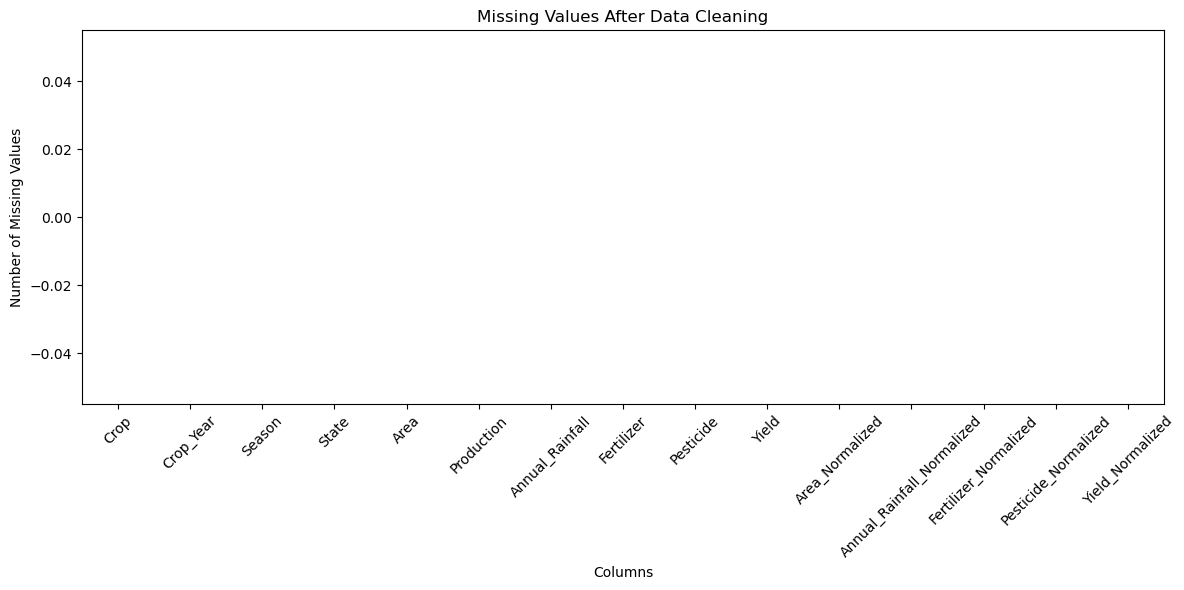

In [29]:
plt.figure(figsize=(12, 6))
df.isnull().sum().plot(kind="bar")
plt.title("Missing Values After Data Cleaning")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

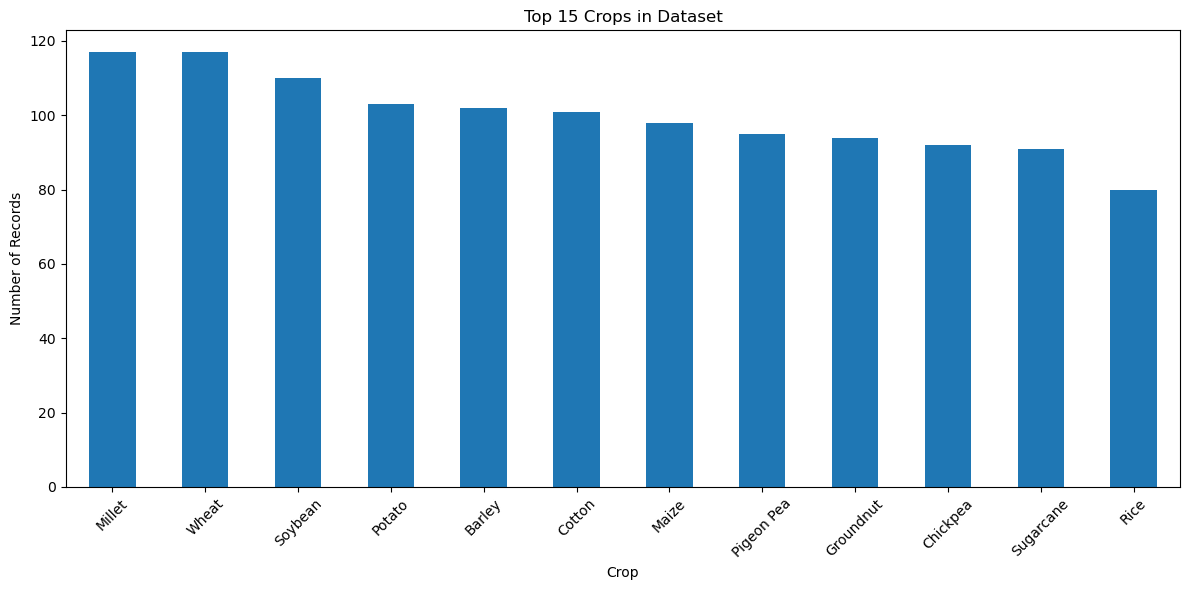

In [30]:
if "Crop" in df.columns:

    plt.figure(figsize=(12, 6))

    df["Crop"].value_counts().head(15).plot(
        kind="bar"
    )

    plt.title("Top 15 Crops in Dataset")

    plt.xlabel("Crop")

    plt.ylabel("Number of Records")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

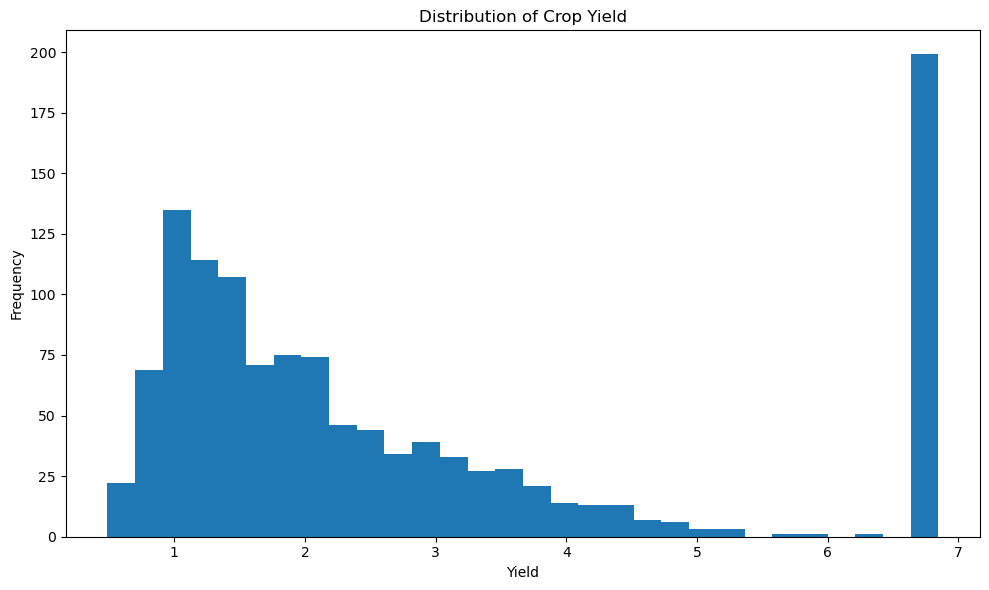

In [31]:
if "Yield" in df.columns:

    plt.figure(figsize=(10, 6))

    plt.hist(
        df["Yield"],
        bins=30
    )

    plt.title("Distribution of Crop Yield")

    plt.xlabel("Yield")

    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.show()

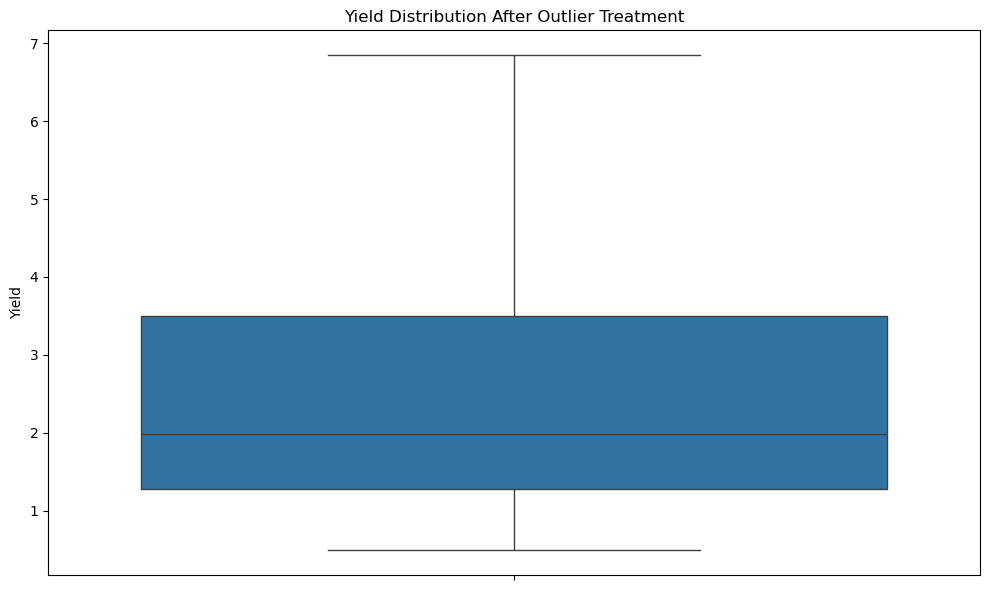

In [32]:
if "Yield" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        y=df["Yield"]
    )

    plt.title(
        "Yield Distribution After Outlier Treatment"
    )

    plt.ylabel("Yield")

    plt.tight_layout()

    plt.show()


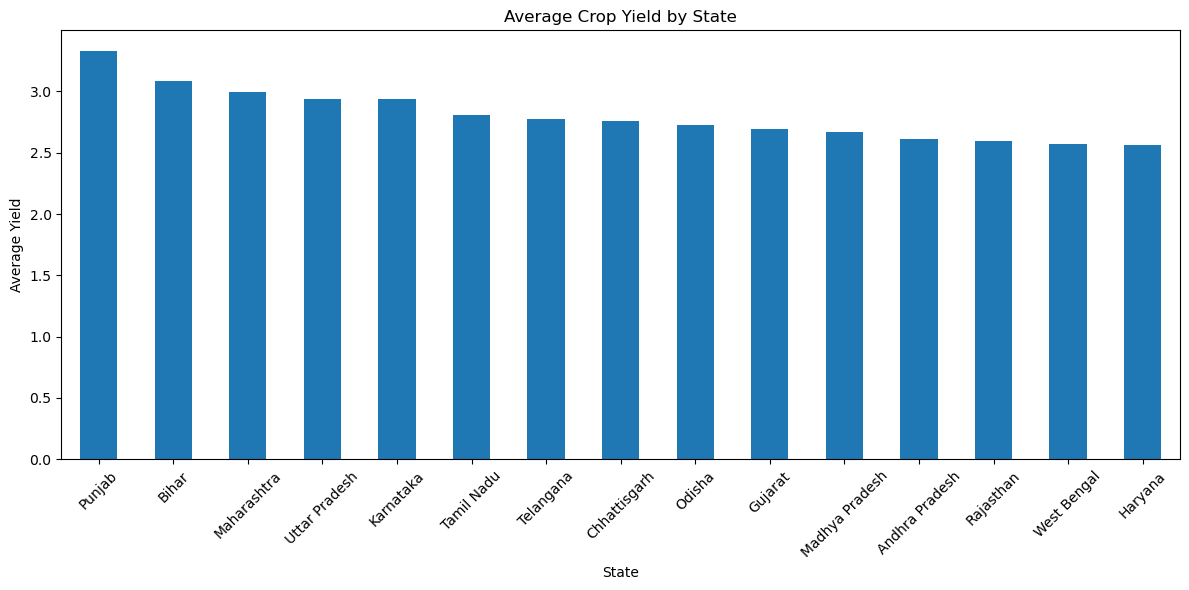

In [33]:
if "State" in df.columns and "Yield" in df.columns:

    state_yield = (
        df.groupby("State")["Yield"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 6))

    state_yield.plot(
        kind="bar"
    )

    plt.title(
        "Average Crop Yield by State"
    )

    plt.xlabel("State")

    plt.ylabel("Average Yield")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

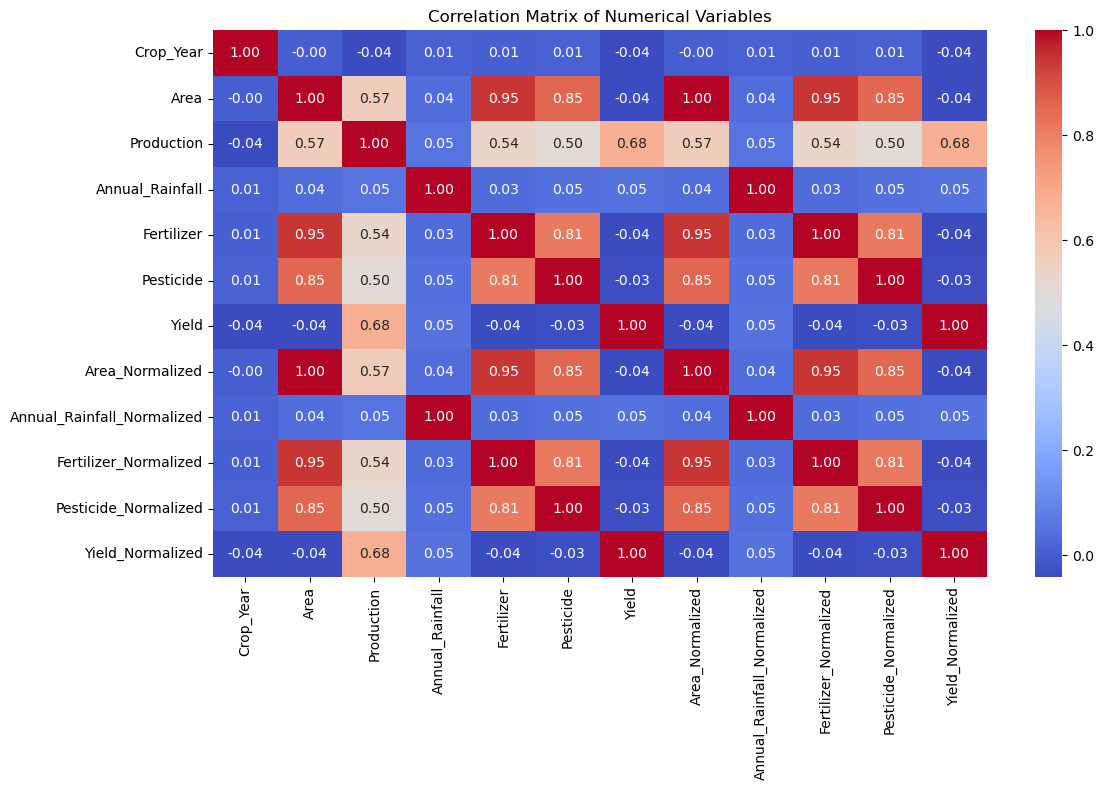

In [34]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Numerical Variables"
)

plt.tight_layout()

plt.show()

## Save Cleaned Dataset

In [35]:
output_file = "cleaned_agriculture_crop_yield.csv"

df.to_csv(
    output_file,
    index=False
)

print("\n================================")
print("DATA CLEANING COMPLETED")
print("================================")

print(
    "Cleaned dataset saved as:",
    output_file
)

print(
    "Final Dataset Shape:",
    df.shape
)


DATA CLEANING COMPLETED
Cleaned dataset saved as: cleaned_agriculture_crop_yield.csv
Final Dataset Shape: (1200, 15)
